# 実行例4.2および4.3 アヤメデータの無相関化と白色化（p.42 図4.4,p.44 図4.6）

In [1]:
using Pkg
Pkg.activate(@__DIR__)
using Statistics
using LinearAlgebra
using DataFrames
using CairoMakie

  Activating project at `c:\Users\salt_\OneDrive\Documents\!勉強\Julia\Pattern_recognition`


## Ⅰ　無相関化

#### 共分散行列 $\Sigma$ の固有値 $\lambda$ と固有ベクトル $s$ の求め方

- `LinearAlgebra`の`eigen`関数を使う。`Symmetric`（対称行列であること）を明示するのがコツ。
- 手順を書き下すと下記となるが3次元以上では厄介
① 固有値 $\lambda$
特異行列の条件（行列式 $\det(\Sigma - \lambda I) = 0$）から、以下の2次方程式（固有方程式）が導かれる（※固有値の定義式 $\Sigma s = \lambda s$ から追っても同じ結果になる）。
$$(\sigma_{11} - \lambda)(\sigma_{22} - \lambda) - \sigma_{12}^2 = 0$$
これを展開して整理する。
$$\lambda^2 - (\sigma_{11} + \sigma_{22})\lambda + (\sigma_{11}\sigma_{22} - \sigma_{12}^2) = 0$$
この2次方程式を解の公式で解いた2つの根が固有値 $\lambda_1, \lambda_2$ 。
② 固有ベクトル $\boldsymbol{s}$
求めたそれぞれの $\lambda$ を $(\Sigma - \lambda I)\boldsymbol{v} = \mathbf{0}$ に代入し、連立方程式を解いてベクトル $\boldsymbol{s} = (s_1, s2)^T$ の比率を求める。
最後に長さ（ノルム）が 1 になるように正規化する。
⚠️ 注意
行列のサイズが $3 \times 3$ 以上になると、この「書き下し（多項式を解く方法）」は計算量が爆発し数値計算の誤差（丸め誤差）も大きくなる。そのため、コードで自作する場合でも既存のアルゴリズム（ヤコビ法やQR分解など）をループで回して近似解を求めるのが一般的。

#### 特異行列（Singular Matrix）とは
- 逆行列 $A^{-1}$ を持たない正方行列
- 行列式が0になる。
$$det(A)=0$$
- 元の行列（この場合は共分散行列）を固有値方向に引き伸ばして線形化する（回転させても元に戻らない）対角行列を作ることができる。各固有値は対応する固有ベクトル方向の分散となる。
$$
\Lambda 
= \begin{pmatrix} \lambda_1 & 0 & \dots & 0 \\
     0 & \lambda_2 & \dots & 0 \\
     \vdots & \ddots & \vdots & \vdots \\
     0 & 0 & \dots & \lambda_d \end{pmatrix} 
$$

### 1. 学習データの読み込み

In [2]:
# (1)iris.csvのファイルパスを設定する
filepath = "iris.csv"

# (2)iris.csvを読み出す
lines = open(filepath, "r") do io
    Iterators.drop(eachline(io), 1) |> collect
end

# (3)学習データ数の確認
N = length(lines)

# (4)データ配列の準備
sepal_length = Float64[]
sepal_width = Float64[]
petal_length = Float64[]
petal_width = Float64[]
Species = String[]

# (5)読み出した行をカンマ区切りのデータ配列にする
for line in lines
    rownames, sepal_length_x, sepal_width_x, petal_length_x, petal_width_x, species_x = split(line, ",")
    push!(sepal_length, parse(Float64, sepal_length_x))
    push!(sepal_width, parse(Float64, sepal_width_x))
    push!(petal_length, parse(Float64, petal_length_x))
    push!(petal_width, parse(Float64, petal_width_x))
    push!(Species, strip(species_x))
end

### 2. 固有値と固有ベクトルの計算
- `eigen`を使うと固有値は昇順で返るためp.40に合わせて降順に入れ替える。
- `reverse()`と`[:, end:-1:1]`で降順にする方法もあるが、固有値と固有ベクトルを個別に並び替えるだけなので避ける。固有値は単純に大きい順。固有ベクトルは最初、固有値に対応して1列目から順に並んでいる。この列の順番だけを入れ替える。
- `Symmetric`で対称行列であることを明示することで、内部的に専用の高速アルゴリズム（`LAPACL`）が選択される。

In [3]:
# (1)共分散行列の計算
Σ = cov([petal_length petal_width])
println("共分散行列: ", round.(Σ, digits=2))

# (2)固有値、固有ベクトルの計算
λ_temp, S_temp = eigen(Symmetric(Σ))
# λ = reverse(λ_temp)
# S = s_temp[:, end:-1:1]
# 降順に並べ替えるためのインデックスを取得
idx = sortperm(λ_temp, rev=true)
# 固有値と固有ベクトルを降順に並べ替える
λ = λ_temp[idx]
S = S_temp[:, idx]
println(det(S))
# S[:, 1] = -S[:, 1]  # 固有ベクトルの符号を反転
println("固有値: ", round.(λ, digits=3))
println("固有ベクトル: ", round.(S, digits=2))

共分散行列: [3.12 1.3; 1.3 0.58]
1.0
固有値: [3.661, 0.036]
固有ベクトル: [-0.92 0.39; -0.39 -0.92]


- そのままの結果の符号は『はじめてのパターン認識』と鏡像の関係になっているが（テキストの行列式は-1、コードの結果は+1）、これは固有空間の「座標軸の向き」が反転している（基底ベクトルの向きが反転している）だけで問題ない。
- ただし元のデータのプロットや図4.4(b)と合わせるため符号を調整しておく。
- 今回は`S[:, 1] = -S[:, 1]`でも調整可能だが、座標が反転するかは結果次第（運任せ）なところがあるため、無相関化後に自動判定（3.(3)鏡像化を防止するための処理）で向きを決める。
- 符号の調整をしないままだと無相関化前後でプロットの左右が反転する（内部の取り扱い的には問題ない）。

### 3. 回転行列による無相関化
- 固有ベクトルを並べた正規直交行列を回転行列として無相関化を図る。
- `S`は列ごとに固有ベクトルが並んでいるので内積を取るのに転置する。

In [4]:
# (1)無相関化されたデータ配列の準備
petal_length_decorrelated = Float64[]
petal_width_decorrelated = Float64[]

# (2)回転行列による無相関化
for i in 1:N
    x = [petal_length[i], petal_width[i]]
    x_rotated = transpose(S) * x
    push!(petal_length_decorrelated, x_rotated[1])
    push!(petal_width_decorrelated, x_rotated[2])
end

In [5]:
# (3)鏡像化を防止するための処理

# ①横軸（Petal Length）の判定と修正
# 元データが「最小」のサンプルのインデックスを見つける
min_idx_x = argmin(petal_length)

if petal_length[min_idx_x] * petal_length_decorrelated[min_idx_x] < 0
    petal_length_decorrelated = -petal_length_decorrelated
end

# ②縦軸（Petal Width）の判定と修正
# 元データが「最小」のサンプルのインデックスを見つける
min_idx_y = argmin(petal_width)

if petal_width[min_idx_y] * petal_width_decorrelated[min_idx_y] < 0
    petal_width_decorrelated = -petal_width_decorrelated
end

### 4. 無相関化されたデータのプロット

無相関化されたデータの平均ベクトル: [3.93, 0.35]
無相関化されたデータの共分散行列: [3.661 0.0; 0.0 0.036]


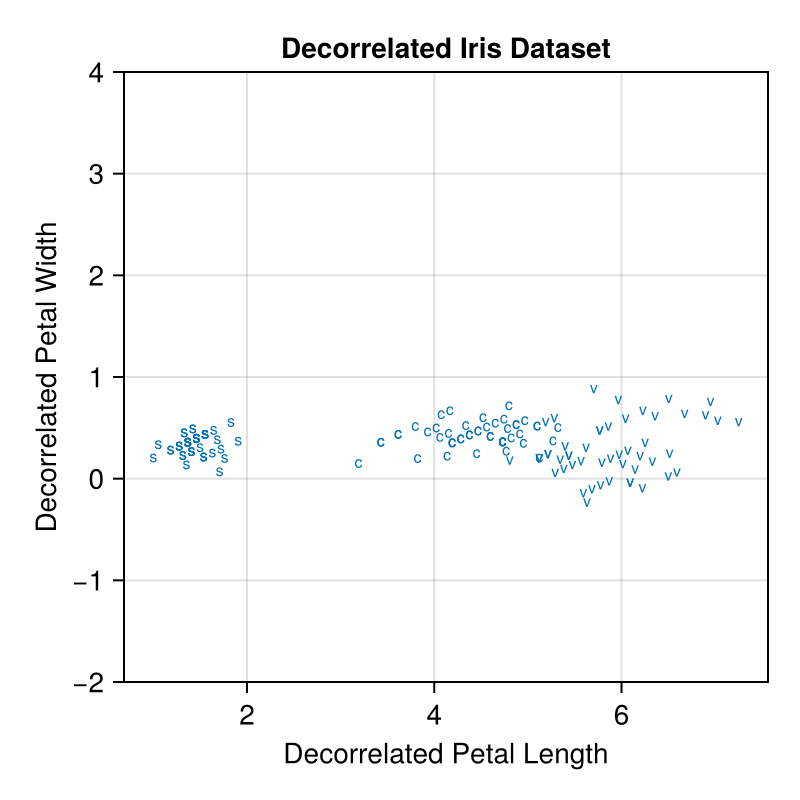

In [6]:
# (1)品種別のマークの配列を準備
markers_dicts = Dict(
    "setosa" => 's',
    "versicolor" => 'c',
    "virginica" => 'v'
)
markers = [markers_dicts[species] for species in Species]

# (2)散布図のプロット
fig = Figure(size = (400, 400))
ax = Axis(fig[1, 1])
plt = scatter!(ax, petal_length_decorrelated, petal_width_decorrelated,
    marker=markers,
    markersize = 8)
ylims!(ax, -2, 4)   # 図4.4(b)に併せてy軸を調整
ax.xlabel = "Decorrelated Petal Length"
ax.ylabel = "Decorrelated Petal Width"
ax.title = "Decorrelated Iris Dataset"

# (3)無相関化されたデータの平均ベクトルと共分散行列の計算
μ_decorrelated = [mean(petal_length_decorrelated), mean(petal_width_decorrelated)]
Σ_decorrelated = cov([petal_length_decorrelated petal_width_decorrelated])
println("無相関化されたデータの平均ベクトル: ", round.(μ_decorrelated, digits=2))
println("無相関化されたデータの共分散行列: ", round.(Σ_decorrelated, digits=3))

# (4)グラフの保存と表示
save("iris_decorrelated_scatter.png", fig)  # 保存
fig # 表示

- `fig`を`println()`の後に持ってくると計算結果もグラフも共に表示される。

## Ⅱ　白色化

### 白色化後の座標系
$$
u = \Lambda^{-1/2} S^{T} (x-\mu)
$$

### 1. 白色化のための行列計算

- 回転行列 $S$：Ⅰ-2で計算済み。
- 対角行列 $\Lambda$：Ⅰ-2で計算済みの共分散行列 $\Sigma$ を使用して $S^{-1} \Sigma S$ を求める。

In [7]:
# (1)回転行列の準備
S = S

# (2)対角行列の準備
Λ = inv(S) * Σ * S
println("Λ: ", round.(Λ, digits=3))
println("Λ^1/2: ", round.(real.(sqrt.(Complex.(Λ))), digits=2))
println("Λ^-1/2: ", round.(inv(real.(sqrt.(Complex.(Λ)))), digits=2))

# (3)平均値の計算
μ = [mean(petal_length), mean(petal_width)]

Λ: [3.661 -0.0; -0.0 0.036]
Λ^1/2: [1.91 0.0; 0.0 0.19]
Λ^-1/2: [0.52 0.0; 0.0 5.27]


2-element Vector{Float64}:
 3.7580000000000005
 1.1993333333333336

- $\Lambda$ は-0.0を取るので、そのまま`sqrt()`で平方根を取ろうとすると定義域エラー`DomainError`になる。そのため`Complex()`で型指定（複素数）した後、実数だけを`real()`関数で取り出している。

### 2. 白色化後の座標系計算

In [8]:
# (1)白色化行列の計算
W = inv(sqrt(Λ)) * transpose(S)

# (2)白色化されたデータ配列の準備
petal_length_whitened = Float64[]
petal_width_whitened = Float64[]

# (3)白色化
for i in 1:N
    x = [petal_length[i], petal_width[i]]
    x_whitened = W * (x - μ)
    push!(petal_length_whitened, x_whitened[1])
    push!(petal_width_whitened, x_whitened[2])
end

# (4)鏡像化を防止するための処理
# ①横軸（Petal Length）の判定と修正
# 元データと白色化されたデータの「最小」と「最大」のサンプルのインデックスを見つける
min_idx_x = argmin(petal_length)
max_idx_x = argmax(petal_length)
if (petal_length[max_idx_x] - petal_length[min_idx_x]) * (petal_length_whitened[max_idx_x] - petal_length_whitened[min_idx_x]) < 0
    petal_length_whitened = -petal_length_whitened
end
# ②縦軸（Petal Width）の判定と修正
# 元データと白色化されたデータの「最小」と「最大」のサンプルのインデックスを見つける
min_idx_y = argmin(petal_width)
max_idx_y = argmax(petal_width)
if (petal_width[max_idx_y] - petal_width[min_idx_y]) * (petal_width_whitened[max_idx_y] - petal_width_whitened[min_idx_y]) < 0
    petal_width_whitened = -petal_width_whitened
end

150-element Vector{Float64}:
 -0.03645982556306748
 -0.03645982556306748
  0.16775530662859062
 -0.24067495775472647
 -0.03645982556306748
  0.321912651639618
  0.4490491113257633
 -0.24067495775472647
 -0.03645982556306748
 -0.7261838946435564
 -0.24067495775472647
 -0.44489008994638546
 -0.5219687624518974
  ⋮
  0.7883686701418249
  1.0196046876583633
  2.067701233941538
  2.603267958011001
  0.6612322104556791
  0.96954690047773
  2.348995038638709
  2.399052825819341
  0.8654473426473368
  0.9425260151528505
  1.9906225614360231
  0.17572327356684925

### 3. 白色化されたデータのプロット

- 品種別マークはⅠ-4のまま使用。

白色化されたデータの平均ベクトル: [-0.0, -0.0]
白色化されたデータの共分散行列: [1.0 -0.0; -0.0 1.0]


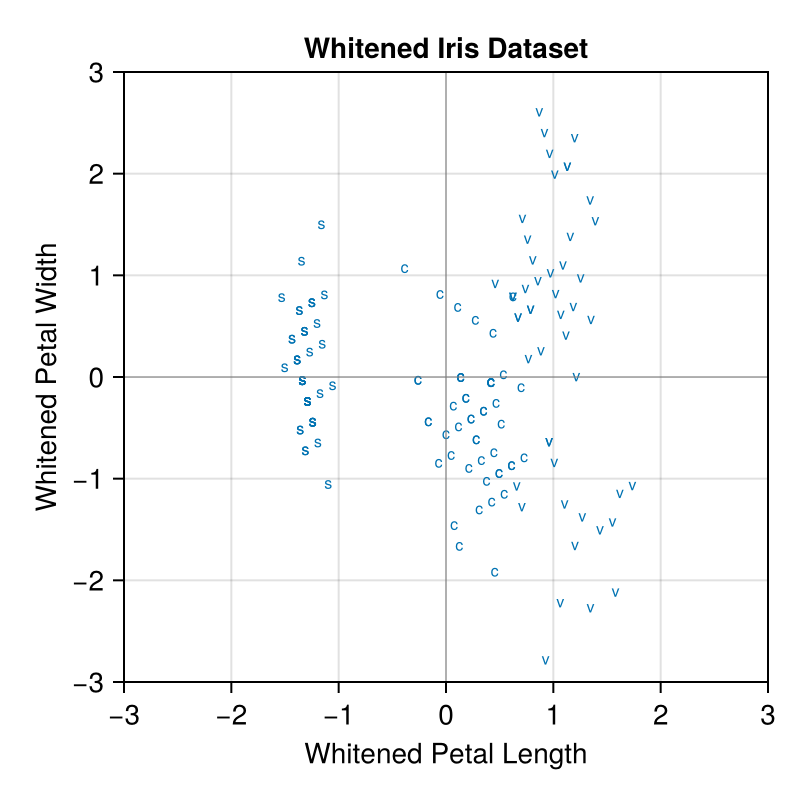

In [9]:
# (1)品種別のマークの配列はⅠ-4で準備したmarkersを再利用

# (2)散布図のプロット
fig = Figure(size = (400, 400))
ax = Axis(fig[1, 1])
plt = scatter!(ax, petal_length_whitened, petal_width_whitened,
    marker=markers,
    markersize = 8)
xlims!(ax, -3, 3)   # 図4.6(b)に併せてx軸を調整
ylims!(ax, -3, 3)   # 図4.6(b)に併せてy軸を調整
vlines!(ax, [0.0], color = :gray50, linewidth = 0.5) # x=0 の縦線
hlines!(ax, [0.0], color = :gray50, linewidth = 0.5) # y=0 の横線
ax.xlabel = "Whitened Petal Length"
ax.ylabel = "Whitened Petal Width"
ax.title = "Whitened Iris Dataset"


# (3)白色化されたデータの平均ベクトルと共分散行列の計算
μ_whitened = [mean(petal_length_whitened), mean(petal_width_whitened)]
Σ_whitened = cov([petal_length_whitened petal_width_whitened])
println("白色化されたデータの平均ベクトル: ", round.(μ_whitened, digits=2))
println("白色化されたデータの共分散行列: ", round.(Σ_whitened, digits=1))

# (4)グラフの保存と表示
save("iris_whitened_scatter.png", fig)  # 保存
fig # 表示